In [1]:
import os
import time
import pandas as pd
import shutil
import io
from datetime import datetime
from PIL import Image
from IPython.display import display, Image as IPImage

# Google Generative AI components
import google.generativeai as genai
from google.generativeai import types

# --- CONFIGURATION ---
DATA_PATH = "words.csv"
KEY_FILE = "gemini_key.txt"
IMAGE_DIR = "icons"
OLD_IMAGE_DIR = os.path.join(IMAGE_DIR, "old_images")
SKIP_EXISTING = True 
RPM_LIMIT = 10        
SLEEP_TIME = 60 / RPM_LIMIT

os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(OLD_IMAGE_DIR, exist_ok=True)

print("Setup updated. io and types imported.")

Setup updated. io and types imported.


e:\Research2\VHPlatform_icon_gen\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Trevor\AppData\Local\Temp\ipykernel_15100\2860301535.py:11: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [2]:
with open(KEY_FILE, "r") as f:
    api_key = f.read().strip()

genai.configure(api_key=api_key)

# We use the specific image-generation model 
# (Note: Use the model name provided in your API console, usually 'imagen-3-fast' or 'gemini-3-flash-image')
model = genai.GenerativeModel('gemini-2.5-flash-image') 

print("API Client initialized.")

API Client initialized.


In [3]:
from PIL import Image, ImageDraw, ImageOps

def apply_app_icon_mask(filepath, radius=180):
    """
    Takes the black and white generation, keeps the center, 
    rounds the corners, and makes the exterior transparent.
    """
    img = Image.open(filepath).convert("RGBA")
    size = img.size
    
    # Create a high-quality mask for rounded corners
    mask = Image.new('L', size, 0)
    draw = ImageDraw.Draw(mask)
    
    # Draw a rounded rectangle (the 'App Icon' shape)
    # radius=180 gives a nice modern 'squircle' feel at 1024px
    draw.rounded_rectangle((0, 0, size[0], size[1]), radius=radius, fill=255)
    
    # Create the final image
    output = Image.new('RGBA', size, (0, 0, 0, 0))
    
    # Paste the original image onto the transparent canvas using the mask
    output.paste(img, (0, 0), mask)
    
    # Optimization: If you want 'smaller' files, we can resize here
    # output = output.resize((256, 256), Image.LANCZOS)
    
    output.save(filepath, "PNG")

print("Post-processing logic defined.")

Post-processing logic defined.


In [4]:
def process_image(word, category, skip_existing=True):
    filename = f"{category}_{word}.png"
    filepath = os.path.join(IMAGE_DIR, filename)
    
    # 1. Versioning Logic
    if os.path.exists(filepath):
        if skip_existing:
            return None
        else:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            old_filepath = os.path.join(OLD_IMAGE_DIR, f"{timestamp}_{filename}")
            shutil.move(filepath, old_filepath)

    # 2. Refined Prompt: Symbolic & Metaphorical
    # We move away from "figure" and toward "symbol" or "representation"
    style_base = "solid white silhouette, centered, pure black background, minimalist flat vector icon, no fine lines, high contrast"
    
    if category == "action":
        # We prompt for a symbol that *represents* the action
        prompt = (f"A {style_base} of a simple symbol or object that represents the action '{word}'. "
                  f"Avoid showing a person if an object or nature symbol (like a snowflake for freezing) is more iconic. "
                  "No text, no shading.")
    else:
        prompt = f"A {style_base} of the object '{word}'. No text, no shading."

    # 3. API Call
    try:
        response = model.generate_content(
            prompt,
            generation_config={"response_modalities": ["IMAGE"]}
        )
        
        for part in response.candidates[0].content.parts:
            if hasattr(part, 'inline_data') and part.inline_data.data:
                with open(filepath, "wb") as f:
                    f.write(part.inline_data.data)
                
                # 4. Apply the Rounded Corner/Transparency Mask
                apply_app_icon_mask(filepath)
                
                return filepath
    except Exception as e:
        print(f"API Error for {word}: {e}")
    
    return None

58
Starting Pilot Test...
Generating action icon for: running


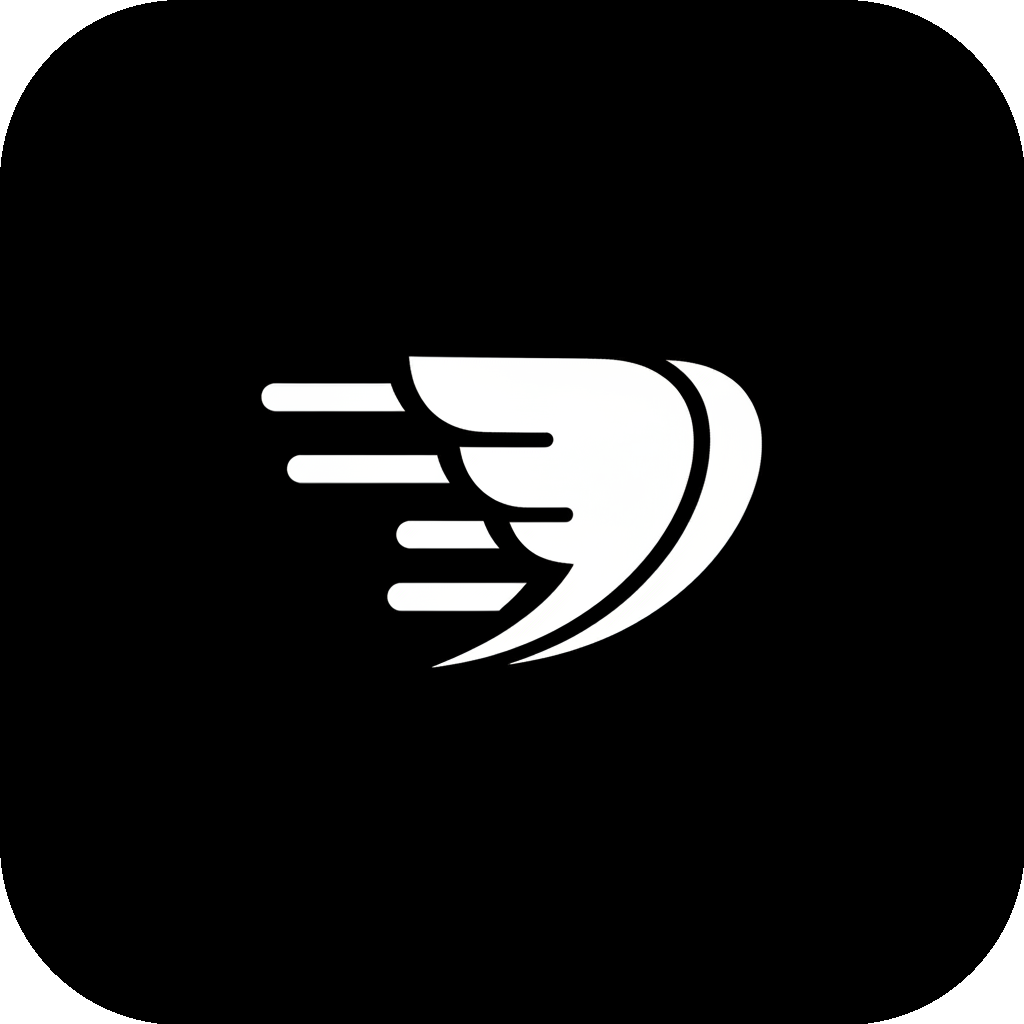

Generating object icon for: raindrop


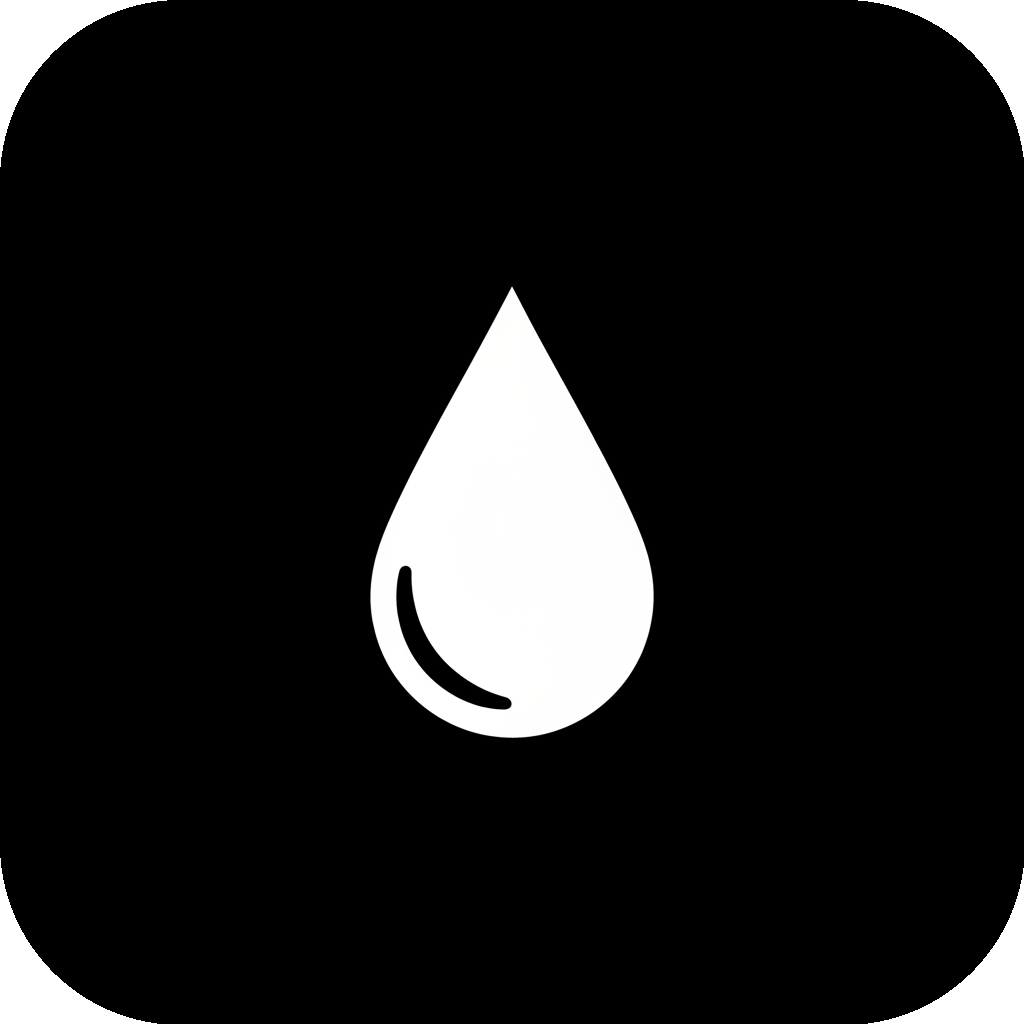

Pilot test complete.


In [ ]:

"""
# Load data
df = pd.read_csv(DATA_PATH)

# Selects 1 random row
test_rows = df.sample(n=1)

# Accesses and prints the index value
print(test_rows.index[0])

print("Starting Pilot Test...")
for index, row in test_rows.iterrows():
    for category in ['action', 'object']:
        word = row[category]
        print(f"Generating {category} icon for: {word}")
        
        # We set skip_existing=False for tests to ensure we see fresh results
        path = process_image(word, category, skip_existing=False)
        
        if path:
            display(IPImage(filename=path, width=150))
            time.sleep(SLEEP_TIME)

print("Pilot test complete.")
"""

In [8]:
print(f"Starting bulk run for {len(df)} pairs...")

for index, row in df.iterrows():
    for category in ['action', 'object']:
        word = row[category]
        
        # This will skip if SKIP_EXISTING is True and the file is there
        path = process_image(word, category, skip_existing=SKIP_EXISTING)
        
        if path:
            print(f"Generated: {path}")
            time.sleep(SLEEP_TIME)
        else:
            # If path is None, it was skipped
            pass

print("All images processed successfully.")

Starting bulk run for 88 pairs...
Generated: icons\action_acting.png
Generated: icons\object_apple.png
Generated: icons\action_biking.png
Generated: icons\object_backpack.png
Generated: icons\action_building.png
Generated: icons\object_banner.png
Generated: icons\action_buying.png
Generated: icons\object_basket.png
Generated: icons\action_camping.png
Generated: icons\object_berry.png
Generated: icons\action_catching.png
Generated: icons\object_bottle.png
Generated: icons\action_checking.png
Generated: icons\object_boulder.png
Generated: icons\action_cheering.png
Generated: icons\object_butter.png
Generated: icons\action_clapping.png
Generated: icons\object_button.png
Generated: icons\action_cleaning.png
Generated: icons\object_candle.png
Generated: icons\action_climbing.png
Generated: icons\object_canvas.png
Generated: icons\action_closing.png
Generated: icons\object_carpet.png
Generated: icons\action_cooking.png
Generated: icons\object_chapter.png
Generated: icons\action_counting.png


Regenerating action icon for: helping...


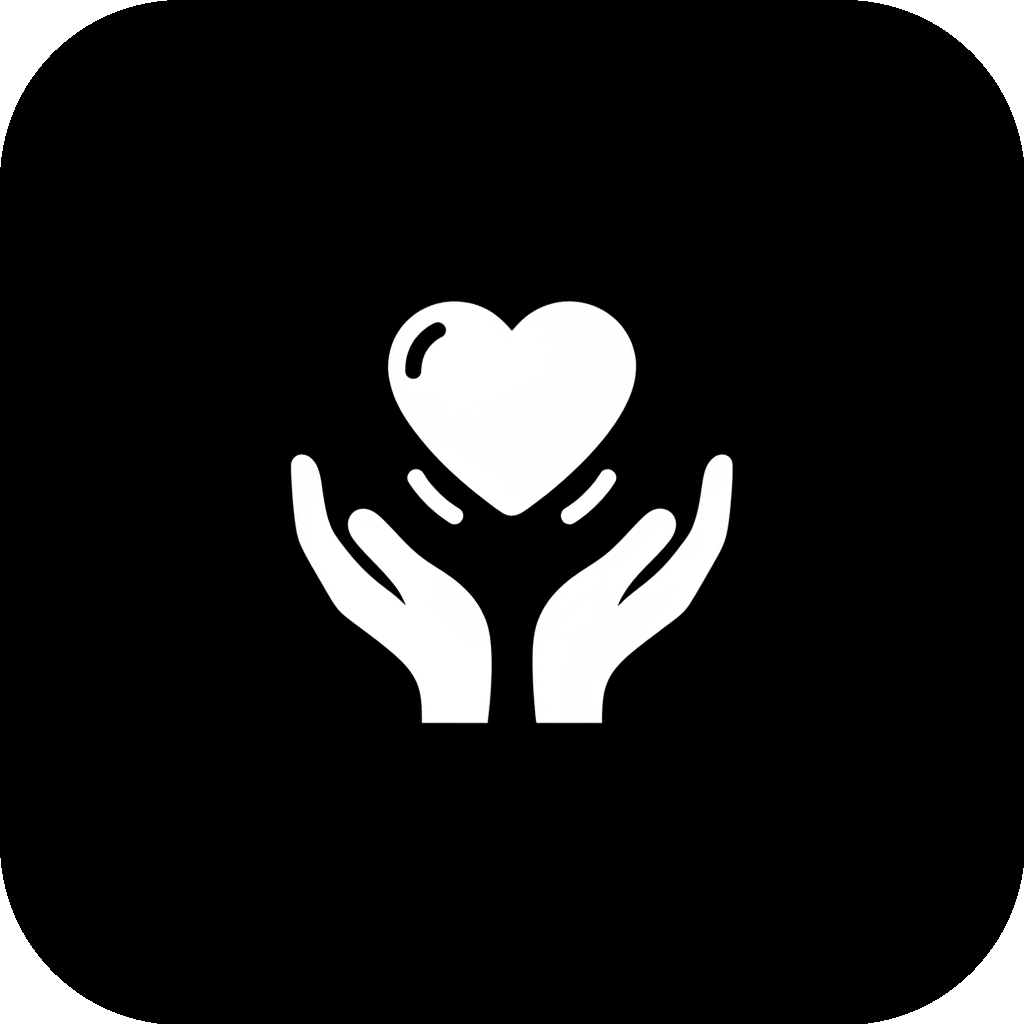

Regenerating action icon for: saving...


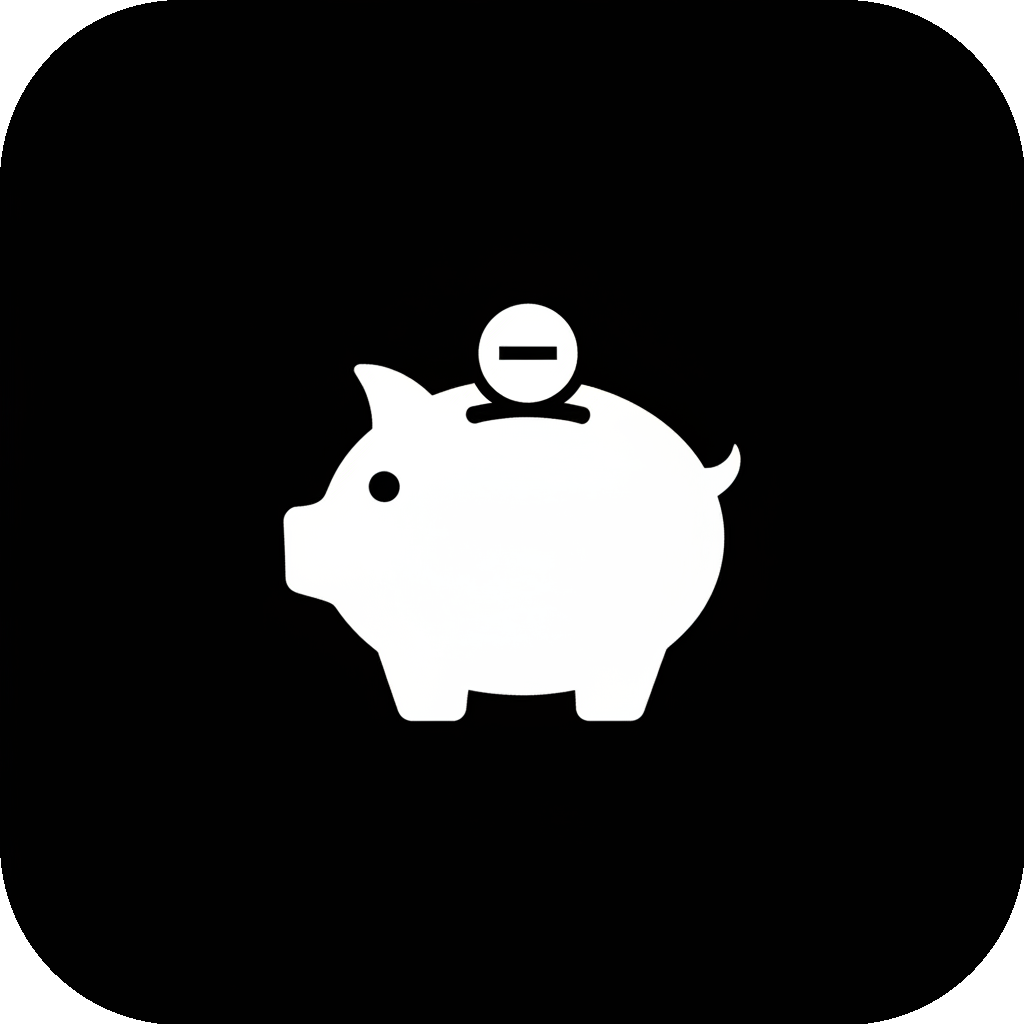

In [ ]:
# --- CONFIGURATION ---
WORDS_TO_REDO = [] # Add any words here

def regenerate_specific_words(word_list):
    df = pd.read_csv(DATA_PATH)
    
    for word in word_list:
        # Determine if it's an action or an object from the CSV
        if word in df['action'].values:
            cat = 'action'
        elif word in df['object'].values:
            cat = 'object'
        else:
            print(f"Skipping '{word}': Not found in {DATA_PATH}")
            continue
            
        print(f"Regenerating {cat} icon for: {word}...")
        # Force skip_existing=False to trigger the 'old_images' versioning
        path = process_image(word, cat, skip_existing=False)
        
        if path:
            display(IPImage(filename=path, width=150))
            time.sleep(SLEEP_TIME)

regenerate_specific_words(WORDS_TO_REDO)

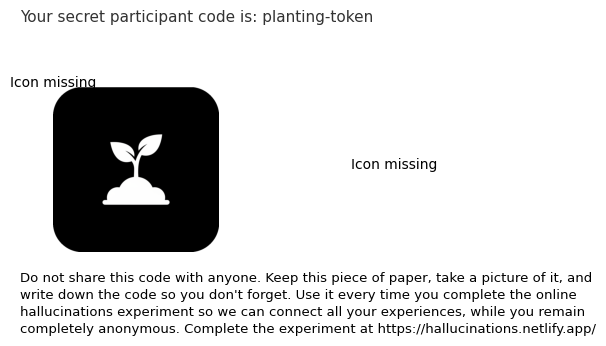

Saved: participant_cards\planting-token.png


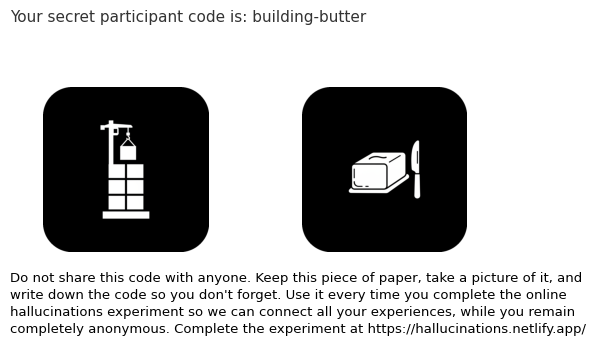

Saved: participant_cards\building-butter.png


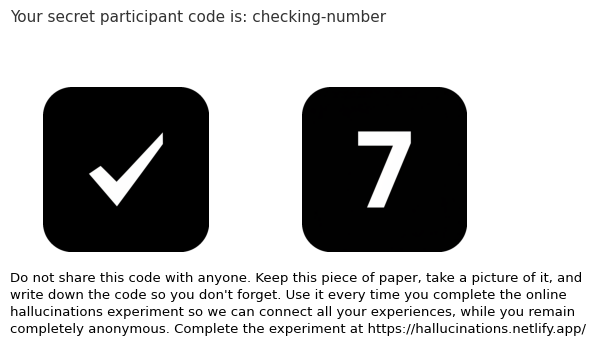

Saved: participant_cards\checking-number.png


In [ ]:
import matplotlib.pyplot as plt
import random
import os
from PIL import Image

# Configuration for saving
OUTPUT_FOLDER = "participant_cards"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

def show_participant_codes(n=3):
    df = pd.read_csv(DATA_PATH)
    actions = df['action'].tolist()
    objects = df['object'].tolist()
    
    random.shuffle(actions)
    random.shuffle(objects)
    
    for i in range(min(n, len(actions))):
        action_word = actions[i]
        object_word = random.choice(objects)
        participant_code = f"{action_word}-{object_word}".lower()
        
        # 1. Compact figure size (Reduced height to eliminate gaps)
        fig = plt.figure(figsize=(7, 5), facecolor='white')
        
        # 2. Combined Header - Instructions and code on one line, left-aligned
        header_text = f"Your secret participant code is: {participant_code}"
        fig.text(0.15, 0.88, header_text, 
                 ha='left', fontsize=11, family='sans-serif', color='#333333')
        
        # 3. Icons - Shifted up closer to the header
        # [left, bottom, width, height]
        ax_act = fig.add_axes([0.15, 0.42, 0.33, 0.33])
        ax_obj = fig.add_axes([0.52, 0.42, 0.33, 0.33])
        
        try:
            act_path = os.path.join(IMAGE_DIR, f"action_{action_word}.png")
            obj_path = os.path.join(IMAGE_DIR, f"object_{object_word}.png")
            
            ax_act.imshow(Image.open(act_path))
            ax_obj.imshow(Image.open(obj_path))
        except FileNotFoundError:
            ax_act.text(0.5, 0.5, "Icon missing", ha='center')
            ax_obj.text(0.5, 0.5, "Icon missing", ha='center')
            
        ax_act.axis('off')
        ax_obj.axis('off')
        
        # 4. Footer Instructions - Positioned tightly below icons
        footer_text = (
            "Do not share this code with anyone. Keep this piece of paper, take a picture of it, "
            "and write down the code so you don't forget. Use it every time you complete the "
            "online hallucinations experiment so we can connect all your experiences, while "
            "you remain completely anonymous. Complete the experiment at https://hallucinations.netlify.app/"
        )
        
        # Align with left icon (0.15), placed just below the icons (0.38)
        fig.text(0.15, 0.38, footer_text, 
                 ha='left', va='top', fontsize=9.5, family='sans-serif', 
                 linespacing=1.4, wrap=True)
        
        # 5. Save the image before showing
        save_path = os.path.join(OUTPUT_FOLDER, f"{participant_code}.png")
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        
        plt.show()
        plt.close(fig)
        print(f"Saved: {save_path}")

# Run the preview and saving process
show_participant_codes(3)